# [IAPR][iapr]: Final project - Chocolate Recognition


**Moodle group ID:** 43  
**Kaggle challenge:** `Deep learning` (either `Classic` or `Deep learning`)  
**Kaggle team name (exact):** "Choco Hunters"  

**Author 1 (sciper):** Ewa Miazga (367059)  
**Author 2 (sciper):** Sameh Lahouar (300454)   
**Author 3 (sciper):** Nour Guermazi (314474) 

**Due date:** 21.05.2025 (11:59 pm)


## Key Submission Guidelines:
- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`
- **Only groups of three will be accepted**, except in exceptional circumstances.


[iapr]: https://github.com/LTS5/iapr2025

---

## 00. Imports

In [1]:
from loader import CocoDataset, UnlabeledImageFolder, VOCDataset, ChocolatePatchDataset, PatchTestDataset
from models.cnn import SimpleCNN
from models.mobile import LightFasterRCNNMobileNetV3
from helper import get_device, draw_boxes_on_image, save_patches, patches_from_coco, collate_fn, save_patches
from trainer import Trainer
from torchvision import transforms
import torchvision
from torch.utils.data import DataLoader, random_split
import torch
import torch.nn as nn
import os 
import cv2
import shutil
import tqdm
import numpy as np
import json
import pandas as pd 
import torchvision.transforms as T
from PIL import Image
from tqdm import tqdm

device = get_device()
print(f"Using device: {device}")

Using device: cuda


## 00.1 Preprocess dataset with coco

In [ ]:
# Cell 2: Define paths and load annotation info
train_img_dir = "dataset_project_iapr2025/train_annotated"
ann_path = os.path.join(train_img_dir, "_annotations.coco.json")

# Load COCO annotations and count classes
with open(ann_path, "r") as f:
    coco_json = json.load(f)
categories = coco_json["categories"]
num_classes = len(categories) + 1  # +1 for background
print("Detected classes:", [c["name"] for c in categories])
print("Total (with background):", num_classes)

# Run it on your dataset
source_path = "dataset_project_iapr2025/train_annotated"
destination_path = "dataset_project_iapr2025/train_patches"
patches_from_coco(source_path, destination_path)

In [ ]:
from torchvision.datasets import CocoDetection

transform = transforms.Compose([
        transforms.Resize((400, 600)),  # Resize to 1400x1400
        transforms.ToTensor(),  # Converts PIL image or ndarray to tensor
    ])

# Load dataset
full_dataset = CocoDetection(root=train_img_dir, annFile=ann_path, transform=transform)

# Optional: Split into train/val
train_len = int(0.8 * len(full_dataset))
val_len = len(full_dataset) - train_len
train_dataset, val_dataset = random_split(full_dataset, [train_len, val_len])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

# just for now 
test_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
print("Train/Val split:", train_len, "/", val_len)
print("display me first label for train dataset")

## Try recognition first 

Create a dataset in Pascal Voc format 

In [ ]:
from torchvision.transforms import Compose, ToTensor

class_names = [
    "Jelly White", "Jelly Milk", "Jelly Black", "Amandina", "Crème brulée",
    "Triangolo", "Tentation noir", "Comtesse", "Noblesse", "Noir authentique",
    "Passion au lait", "Arabia", "Stracciatella"
]

# Example label mapping (fill this in based on your dataset)
label_map = {
    "Jelly_White": 1,
    "Jelly_Milk": 2,
    "Jelly_Black": 3,
    "Amandina": 4,
    "Creme_brulee": 5,
    "Triangolo": 6,
    "Tentation_noir": 7,
    "Comtesse": 8,
    "Noblesse": 9,
    "Noir_authentique": 10,
    "Passion_au_lait": 11,
    "Arabia": 12,
    "Stracciatella": 13
}

label_map_inv = {v: k for k, v in label_map.items()}

transform = Compose([
    ToTensor()
])


full_dataset = VOCDataset("dataset_project_iapr2025_voc/train", transform=transform, label_map=label_map)
# check if path exists
if not os.path.exists("dataset_project_iapr2025_voc/train"):
    raise FileNotFoundError("Dataset path does not exist.")

# Optional: Split into train/val
train_len = int(0.8 * len(full_dataset))
val_len = len(full_dataset) - train_len
train_dataset, val_dataset = random_split(full_dataset, [train_len, val_len])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


# Dataset and loader
test_dir = "dataset_project_iapr2025/test"
test_dataset = UnlabeledImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train/Val split:", train_len, "/", val_len)
print("Test dataset size:", len(test_loader.dataset))

In [ ]:
# Define the number of classes (including background)
num_classes = 14  # Example: 1 class (e.g., 'chocolate') + 1 background

# Initialize the model without pretrained weights
model = torchvision.models.detection.ssdlite320_mobilenet_v3_large(weights=None)

# Replace the classifier with a new one for your number of classes
model.head.classification_head.num_classes = num_classes

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.to(device)

In [ ]:
import torch.optim as optim

# Define the optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 30

trainer = Trainer(model=model,
                  model_name="SSDLiteMobileNetV3",
                      optimizer=optimizer,
                      scheduler=scheduler,
                      num_epochs =num_epochs,
                      train_loader=train_loader,
                      val_loader=val_loader,
                      test_loader=test_loader,
                      device=device)

trainer.train()


In [ ]:
#trainer.save_model()

Run predictions

In [ ]:
model = trainer.load_model(model_name="SSDLiteMobileNetV3_Trained.pth")

In [ ]:
avg_loss, overall_accuracy, overall_f1, per_class_f1, images_out = trainer.evaluate()
print(f"Average Loss: {avg_loss}, Overall Accuracy: {overall_accuracy}%, Overall F1: {overall_f1}")

per_class_f1 = per_class_f1[1:]  # Drop the background class

for i, f1 in enumerate(per_class_f1):
    print(f"Class {i+1}: {class_names[i]} - F1 Score: {f1}")

In [ ]:
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

def visualize_sample(sample, score_threshold=0.3):
    image = sample["image_tensor"]
    gt_boxes = sample["gt_boxes"]
    gt_labels = sample["gt_labels"]
    pred_boxes = sample["pred_boxes"]
    pred_labels = sample["pred_labels"]
    pred_scores = sample["pred_scores"]

    # Filter predictions by confidence threshold
    keep = pred_scores > score_threshold
    pred_boxes = pred_boxes[keep]
    pred_labels = pred_labels[keep]
    pred_scores = pred_scores[keep]

    # Convert image to uint8 and unnormalize if needed
    if image.max() <= 1.0:
        image = (image * 255).to(torch.uint8)

    # Draw ground truth boxes (green)
    image_with_gt = torchvision.utils.draw_bounding_boxes(
        image.clone(),
        gt_boxes,
        labels=[str(l.item()) for l in gt_labels],
        colors="green",
        width=10
    )

    # Draw predicted boxes (red)
    image_with_preds = torchvision.utils.draw_bounding_boxes(
        image_with_gt,
        pred_boxes,
        labels=[f"{l.item()} ({s:.2f})" for l, s in zip(pred_labels, pred_scores)],
        colors="red",
        width=10
    )

    # Convert to PIL and show
    plt.figure(figsize=(10, 10))
    plt.imshow(F.to_pil_image(image_with_preds))
    plt.axis("off")
    plt.title("Green = Ground Truth, Red = Prediction")
    plt.show()

In [ ]:
for i in range(5):
    visualize_sample(images_out[i], score_threshold=0.3)
    print("Visualized sample", i+1)

In [ ]:
preds = trainer.predict()

In [ ]:
import pandas as pd
import re
from collections import Counter

# Your predictions list
predictions = preds  # Replace with your actual list

# Class names (position corresponds to label - 1)
class_names = [
    "Jelly White", "Jelly Milk", "Jelly Black", "Amandina", "Crème brulée", "Triangolo",
    "Tentation noir", "Comtesse", "Noblesse", "Noir authentique", "Passion au lait", "Arabia", "Stracciatella"
]

rows = []

for pred in predictions:
    filename = pred["filename"]
    labels = pred["labels"].tolist()

    # Clean filename to get numeric ID
    match = re.search(r'(\d+)', filename)
    img_id = match.group(1) if match else filename

    # Shift labels to be 0-based
    shifted_labels = [label - 1 for label in labels if 1 <= label <= len(class_names)]

    # Count class occurrences
    label_counter = Counter(shifted_labels)

    # Build row of class counts
    class_counts = [label_counter.get(i, 0) for i in range(len(class_names))]

    rows.append([img_id] + class_counts)

# Create DataFrame and export
df = pd.DataFrame(rows, columns=["id"] + class_names)
df.to_csv("predictions_counts.csv", index=False)

Save patches

In [ ]:
output_image_dir = "results/drawn_images"
output_patch_dir = "dataset_project_iapr2025/test_patches"
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_patch_dir, exist_ok=True)

for pred in preds:
    filename = pred["filename"]
    boxes = pred["boxes"]
    labels = pred["labels"]
    scores = pred["scores"]

    # Save image with boxes
    drawn = draw_boxes_on_image(filename, boxes, labels, scores, label_map_inv)
    cv2.imwrite(filename, drawn)

    # Save patches
    save_patches(filename, boxes, labels, scores, label_map_inv, output_patch_dir, threshold=0.1)

# Patches 

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

# === 1. Load CSV and create label map ===
csv_path = "dataset_project_iapr2025/train_patches/patches/labels.csv"
image_dir = "dataset_project_iapr2025/train_patches/patches"

df = pd.read_csv(csv_path, dtype={'name': str})
class_names = sorted(df['label'].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}
df['class_idx'] = df['label'].map(class_to_idx)

# === 2. Train/val split ===
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['class_idx'], random_state=42)

# move labels 1 up
train_df['class_idx'] = train_df['class_idx'] + 1
val_df['class_idx'] = val_df['class_idx'] + 1

# === 3. Define transform ===
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# === 5. Create datasets and loaders ===
train_dataset = ChocolatePatchDataset(train_df, image_dir, transform)
val_dataset = ChocolatePatchDataset(val_df, image_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dir = "dataset_project_iapr2025/test_patches"
test_dataset = PatchTestDataset(test_dir, transform=transform)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# === 6. Check dataset size ===
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
# === 7. Check first label ===
print("First label in train dataset:", train_dataset[0][1].item())

### training for CNN

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

class_number = 14 #len(full_dataset.coco.cats)
model = SimpleCNN(input_shape=3, hidden_units=64, image_height=128, image_width=128, output_shape=class_number)
loss_fn = nn.CrossEntropyLoss()

#optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

trainer = Trainer(model=model,
                  model_name="SimpleCNN",
                      loss_fn=loss_fn,
                      optimizer=optimizer,
                      scheduler=scheduler,
                      num_epochs=10,
                      train_loader=train_loader,
                      val_loader=val_loader,
                      test_loader=test_loader,
                      device=device)

# trainer.train()
# avg_loss, overall_accuracy, overall_f1, per_class_f1 = trainer.evaluate()
# trainer.save_model()

In [ ]:
model = trainer.load_model(DIR = "output/", model_name="SimpleCNN_Trained.pth")
avg_loss, overall_accuracy, overall_f1, per_class_f1 = trainer.evaluate()
print(f"Average Loss: {avg_loss}, Overall Accuracy: {overall_accuracy}%, Overall F1: {overall_f1}")

for i, f1 in enumerate(per_class_f1):
    print(f"Class {i+1}: {class_names[i]} - F1 Score: {f1}")

predict and group the results 

In [ ]:
predictions = trainer.predict()
print(len(predictions))

In [ ]:
print(predictions[0])

In [ ]:
from collections import defaultdict

grouped = defaultdict(list)
for pred in predictions:
    grouped[pred["image_id"]].append(pred["pred_class"])

# Example:
for image_id, patch_preds in grouped.items():
    print(f"{image_id}: {patch_preds}")

prepare submission file

In [ ]:
grouped_preds = defaultdict(set)

class_name_to_id = {name: i+1 for i, name in enumerate(class_names)}
class_id_to_name = {v: k for k, v in class_name_to_id.items()}

for p in predictions:
    image_id = p["image_id"].lstrip("L").split("_")[0]  # remove "L" prefix etc
    label = class_id_to_name[p["pred_class"]]
    grouped_preds[image_id].add(label)

submission = []

for image_id in sorted(grouped_preds.keys()):
    print(grouped_preds[image_id])
    row = {"id": image_id}
    for cname in class_names:
        row[cname] = 1 if cname in grouped_preds[image_id] else 0
    submission.append(row)

df_sub = pd.DataFrame(submission)
df_sub = df_sub[["id"] + class_names]  # ensure correct column order

df_sub.to_csv("outputs/cnn_submission.csv", index=False)
print("✅ submission.csv created!")

In [ ]:
from collections import defaultdict, Counter
import pandas as pd
import os

# Map class names to IDs (starting at 1)
class_name_to_id = {name: i+1 for i, name in enumerate(class_names)}
class_id_to_name = {v: k for k, v in class_name_to_id.items()}

# Create a dictionary to store counts per image
grouped_counts = defaultdict(Counter)

# Loop over predictions and count class occurrences per image
for p in predictions:
    image_id = p["image_id"].lstrip("L").split("_")[0]  # clean image name
    class_name = class_id_to_name[p["pred_class"]]
    grouped_counts[image_id][class_name] += 1

# Build submission rows
submission = []

for image_id in sorted(grouped_counts.keys()):
    row = {"id": image_id}
    for cname in class_names:
        row[cname] = grouped_counts[image_id][cname]  # 0 if absent
    submission.append(row)

# Build DataFrame
df_sub = pd.DataFrame(submission)
df_sub = df_sub[["id"] + class_names]  # Ensure correct column order

# Save CSV
os.makedirs("outputs", exist_ok=True)
df_sub.to_csv("outputs/cnn_submission.csv", index=False)

print("✅ cnn_submission.csv created!")


# Sameh

Prepare the dataset

In [2]:
# Cell 2: Define paths and load annotation info
train_img_dir = "dataset_project_iapr2025/train_augmented"
ann_path = "dataset_project_iapr2025/train_augmented/_annotations.coco.json"

# Load COCO annotations and exclude "objects" class
with open(ann_path, "r") as f:
    coco_json = json.load(f)

# ✅ Exclude 'objects' and assign label IDs starting from 1
categories = [cat for cat in coco_json["categories"] if cat["name"] != "objects"]
class_name_to_id = {cat["name"]: i + 1 for i, cat in enumerate(categories)}
num_classes = max(class_name_to_id.values()) + 1  # +1 for background class 0

# Display the class structure
print("Detected classes (excluding 'objects'):", list(class_name_to_id.keys()))
print("Total (with background):", num_classes)


Detected classes (excluding 'objects'): ['Amandina', 'Arabia', 'Comtesse', 'Creme_brulee', 'Jelly_Black', 'Jelly_Milk', 'Jelly_White', 'Noblesse', 'Noir_authentique', 'Passion_au_lait', 'Stracciatella', 'Tentation_noir', 'Triangolo']
Total (with background): 14


In [3]:
def get_transform():
    return T.Compose([
        T.ToTensor(),  # Converts PIL image to tensor
    ])

# This collate_fn works for batched Faster R-CNN inputs
def collate_fn(batch):
    return tuple(zip(*batch))

# Load full dataset (with all classes including "objects")
full_dataset = CocoDataset(
    root=train_img_dir,
    annotation=ann_path,
    transform=get_transform()
)

# Split full dataset into 90% train / 10% validation
total_len = len(full_dataset)
train_len = int(0.9 * total_len)
val_len = total_len - train_len

train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_len, val_len])

test_image_dir = "dataset_project_iapr2025/test"
unlabeled_dataset = UnlabeledImageFolder(test_image_dir)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(unlabeled_dataset, batch_size=1, shuffle=False)

print(f"Loaded full dataset: {total_len} images -> {train_len} train / {val_len} val")

Loaded full dataset: 270 images -> 243 train / 27 val


Train the model 

In [ ]:
model = LightFasterRCNNMobileNetV3(num_classes=num_classes)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
epochs = 150

trainer = Trainer(model=model,
                  model_name="MobileNetV3",
                      optimizer=optimizer,
                      num_epochs=epochs,
                      train_loader=train_loader,
                      val_loader=val_loader,
                      test_loader=test_loader,
                      device=device)

trainer.train()
#avg_loss, overall_accuracy, overall_f1, per_class_f1 = trainer.evaluate()

In [ ]:
trainer.save_model(model_name="MobileNetV3Augmentedasasasa.pth")

Import the Model without retraining

In [4]:
model = LightFasterRCNNMobileNetV3(num_classes=num_classes)
epochs = 150
checkpoint_path = "output/MobileNetV3Augmented.pth"  # replace with your path
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
trainer = Trainer(model=model,
                  model_name="MobileNetV3",
                      optimizer=optimizer,
                      num_epochs=epochs,
                      train_loader=train_loader,
                      val_loader=val_loader,
                      test_loader=test_loader,
                      device=device)

Total parameters:         10453044
Backbone (MobileNet):     1371344
RPN:                      597790
ROI Heads (Box Head):     8483910


C:\Users\sameh\AppData\Local\Temp\ipykernel_7404\1903005395.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_locatio

In [5]:
avg_loss, overall_accuracy, overall_f1, per_class_f1,_ = trainer.evaluate()
print(f"Average Loss: {avg_loss}, Overall Accuracy: {overall_accuracy}%, Overall F1: {overall_f1}")
print(f"Per Class F1: {per_class_f1}")
per_class_f1 = per_class_f1[1:]  # Drop the background class
for i, f1 in enumerate(per_class_f1):
    print(f"Class {i}: {categories[i]} - F1 Score: {f1}")

100%|██████████| 14/14 [00:04<00:00,  2.93it/s]

Batch [14], Loss: 3.7489
Average Loss: 0.24992736677328745, Overall Accuracy: 0.9710982658959537%, Overall F1: 0.9816224707330431
Per Class F1: [0.         1.         0.96774194 1.         1.         0.92307692
 1.         0.9        1.         1.         0.96296296 1.
 1.         1.        ]
Class 0: {'id': 1, 'name': 'Amandina', 'supercategory': 'objects'} - F1 Score: 1.0
Class 1: {'id': 2, 'name': 'Arabia', 'supercategory': 'objects'} - F1 Score: 0.967741935483871
Class 2: {'id': 3, 'name': 'Comtesse', 'supercategory': 'objects'} - F1 Score: 1.0
Class 3: {'id': 4, 'name': 'Creme_brulee', 'supercategory': 'objects'} - F1 Score: 1.0
Class 4: {'id': 5, 'name': 'Jelly_Black', 'supercategory': 'objects'} - F1 Score: 0.9230769230769231
Class 5: {'id': 6, 'name': 'Jelly_Milk', 'supercategory': 'objects'} - F1 Score: 1.0
Class 6: {'id': 7, 'name': 'Jelly_White', 'supercategory': 'objects'} - F1 Score: 0.9
Class 7: {'id': 8, 'name': 'Noblesse', 'supercategory': 'objects'} - F1 Score: 1.0
Cla

Extracting predictions: 100%|██████████| 14/14 [00:01<00:00, 11.85it/s]


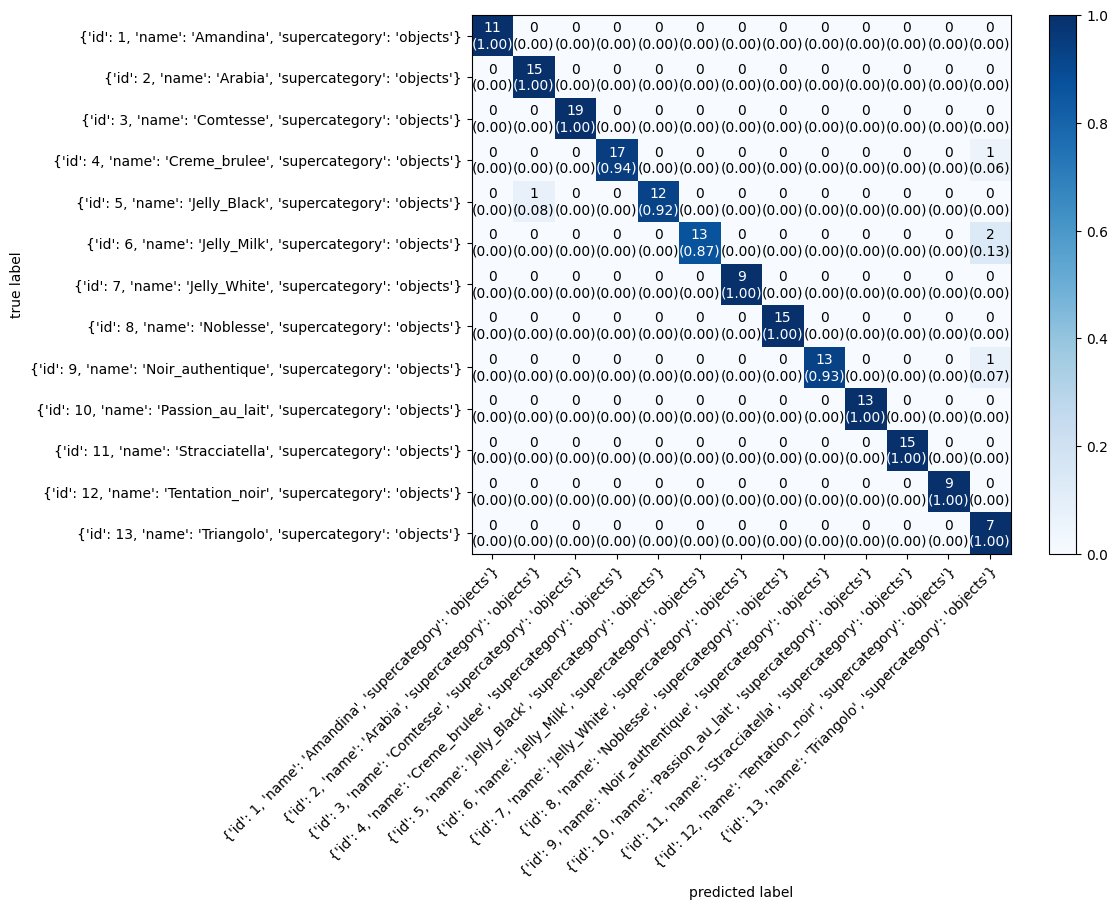

In [6]:
from helper import get_confussion_matrix
y_true, y_pred = trainer.get_val_predictions()

# Ensure they're tensors
y_true = torch.tensor(y_true)
y_pred = torch.tensor(y_pred)


get_confussion_matrix(
    y_pred=y_pred,
    y_true=y_true,
    num_classes=len(categories) + 1,  # full number of classes incl. background
    class_names=categories           # should not include background class name
)

Test the model

In [ ]:
predictions = trainer.predict()

print(f"1 predition: {predictions[0]}")

Save the model

In [ ]:
trainer.save_model(model_name="MobileNetV3Augmented.pth")